In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [9]:
date_rng = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
orders = 2500

df = pd.DataFrame({
    'OrderID': range(1000, 1000 + orders),
    'Date': np.random.choice(date_rng, orders),
    'ProductCategory': np.random.choice(['Electronics', 'Clothing', 'Furniture', 'Office Supplies'], orders),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], orders),
    'Quantity': np.random.randint(1, 10, size=orders),
    'UnitPrice': np.random.uniform(10.0, 500.0, size=orders),
    'Discount': np.random.choice([0.0, 0.1, 0.15, 0.2], orders),
    'CustomerSegment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], orders)
})

df['TotalSales'] = (df['Quantity'] * df['UnitPrice']) * (1 - df['Discount'])
df['Profit'] = df['TotalSales'] * np.random.uniform(0.05, 0.3, size=orders)

df.head()

,OrderID,Date,ProductCategory,Region,Quantity,UnitPrice,Discount,CustomerSegment,TotalSales,Profit
0,1000,2023-05-31,Furniture,South,8,412.254397,0.10,Corporate,2968.231659,613.080312
1,1001,2023-10-25,Clothing,North,2,84.537571,0.10,Corporate,152.167628,8.394633
2,1002,2023-03-07,Clothing,North,8,354.471095,0.15,Consumer,2410.403444,715.400214
3,1003,2023-02-20,Furniture,East,8,235.222519,0.10,Home Office,1693.602137,184.665754
4,1004,2023-11-29,Clothing,North,4,126.066309,0.00,Corporate,504.265235,151.075911


In [10]:
display(df.info())

display(df.isnull().sum())

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          2500 non-null   int64         
 1   Date             2500 non-null   datetime64[us]
 2   ProductCategory  2500 non-null   str           
 3   Region           2500 non-null   str           
 4   Quantity         2500 non-null   int32         
 5   UnitPrice        2500 non-null   float64       
 6   Discount         2500 non-null   float64       
 7   CustomerSegment  2500 non-null   str           
 8   TotalSales       2500 non-null   float64       
 9   Profit           2500 non-null   float64       
dtypes: datetime64[us](1), float64(4), int32(1), int64(1), str(3)
memory usage: 185.7 KB


None

OrderID            0
Date               0
ProductCategory    0
Region             0
Quantity           0
UnitPrice          0
Discount           0
CustomerSegment    0
TotalSales         0
Profit             0
dtype: int64

,OrderID,Date,Quantity,UnitPrice,Discount,TotalSales,Profit,Month,Year
count,2500.00000,2500,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.0
mean,2249.50000,2023-07-04 14:18:14.400000,5.012400,259.208434,0.113960,1137.718129,199.737433,6.607600,2023.0
min,1000.00000,2023-01-01 00:00:00,1.000000,10.415659,0.000000,9.712022,0.592196,1.000000,2023.0
25%,1624.75000,2023-04-06 18:00:00,3.000000,137.715374,0.100000,386.543595,57.788812,4.000000,2023.0
50%,2249.50000,2023-07-05 00:00:00,5.000000,255.282739,0.150000,896.136804,135.147379,7.000000,2023.0
75%,2874.25000,2023-09-30 00:00:00,7.000000,385.810361,0.200000,1698.953636,278.628484,9.000000,2023.0
max,3499.00000,2023-12-31 00:00:00,9.000000,499.880652,0.200000,4434.239731,1193.726160,12.000000,2023.0
std,721.83216,NaN,2.577228,142.412843,0.073928,906.317921,193.959641,3.396798,0.0


In [11]:
category_sales = df.groupby('ProductCategory')[['TotalSales', 'Profit']].sum().sort_values(by='TotalSales', ascending=False)
display(category_sales)

monthly_sales = df.groupby('Month')['TotalSales'].sum().reset_index()
display(monthly_sales)

segment_sales = df.groupby('CustomerSegment')['TotalSales'].sum().sort_values(ascending=False)
display(segment_sales.to_frame())

,TotalSales,Profit
ProductCategory,,
Clothing,775205.366053,138360.515323
Office Supplies,740462.446731,132542.400209
Electronics,679088.785586,116456.698842
Furniture,649538.725019,111983.968526


,Month,TotalSales
0,1,221836.205224
1,2,205644.040406
2,3,246619.489077
3,4,234015.628429
4,5,204056.642850
5,6,239334.511582
6,7,215345.002462
7,8,278374.814678
8,9,256103.577748
9,10,272975.522984


,TotalSales
CustomerSegment,
Consumer,989137.614213
Home Office,945893.168833
Corporate,909264.540342


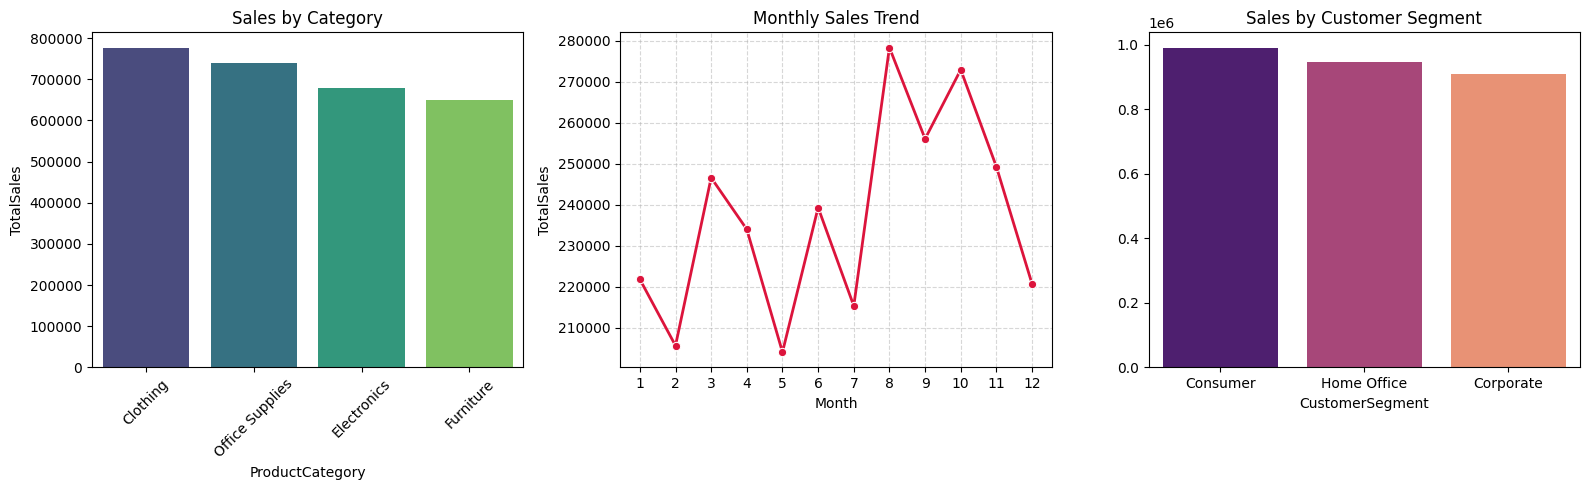

In [12]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=category_sales.index, y=category_sales['TotalSales'], hue=category_sales.index, palette='viridis', legend=False)
plt.title('Sales by Category')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.lineplot(x=monthly_sales['Month'], y=monthly_sales['TotalSales'], marker='o', color='crimson', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 3, 3)
sns.barplot(x=segment_sales.index, y=segment_sales.values, hue=segment_sales.index, palette='magma', legend=False)
plt.title('Sales by Customer Segment')

plt.tight_layout()
plt.show()